# Stream-CQSA reference kernels — how the decomposition works

This notebook uses the **pure-PyTorch reference implementation** that ships in
`stream_cqsa.backends.exact`. It is *not* the fast path — the production CUDA
kernel is in `stream_cqsa.stable_stream`, and it is one to two orders of
magnitude faster. The reference exists to make the idea legible: every step is
an ordinary tensor operation you can print, plot, and differentiate.

We show four things:

1. **The CQS decomposition partitions the attention pairs** — 7 subproblems
   (at depth 1) whose union is *exactly* the full N x N pair set, no more and no
   less.
2. **The reference runner reproduces dense attention** at every depth.
3. **The inner kernel is pluggable** — swap the dense one for a blocked,
   out-of-core one without touching the decomposition.
4. **Why the production kernel is written differently** — the natural
   `Num`/`Den` formulation used here fails *silently* at realistic score
   magnitudes, and that failure is the reason the shipped kernel never forms
   `exp(lse)`.

> **Scale.** The dense inner kernel materializes the full local score matrix, so
> keep `N` in the hundreds or low thousands here. Use `stream_cqsa_auto` for
> anything real.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from stream_cqsa.cqs_mask import CQS_mask
from stream_cqsa.backends.exact import (
    DenseExactInnerKernel,
    RectangularOutOfCoreInnerKernel,
    stream_cqsa_exact_reference,
    dense_attention_num_den,
    normalize_num_den,
)

DEV = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEV, "|", torch.cuda.get_device_name(0) if DEV == "cuda" else "")

# CQS parameters: c=7 chunks, interest set (0,1,3) is a lambda=1 Singer
# difference set, which is what makes the quorums cover every pair exactly once.
C_CHUNKS, INTEREST = 7, (0, 1, 3)
mask_engine = CQS_mask(interest_set=INTEREST, c=C_CHUNKS)

device: cuda | NVIDIA A100-PCIE-40GB


## 1. The decomposition partitions the pairs

At depth `itr`, Stream-CQSA produces `c**itr` subproblems. Each one selects a
subset of tokens (`token_ids`) and attends only within that subset, with a local
mask that removes the pairs another subproblem is responsible for.

The property that makes this *exact* rather than approximate: the union of the
pairs covered by all subproblems is the complete N x N grid. `validate_pair_coverage`
checks it by construction.

In [2]:
N_SMALL = 256
rows = []
for depth, quorum in ((0, [0]), (1, [0, 0]), (2, [0, 0, 0])):
    cov = mask_engine.validate_pair_coverage(N=N_SMALL, quorum_idx=quorum)
    rows.append((depth, cov["num_subgrids"], cov["union_size"],
                 cov["total_pairs"], cov["covered"]))

print(f"{'itr':>4} {'subproblems':>12} {'pairs covered':>14} {'pairs total':>12} {'exact?':>7}")
for d, n, u, t, ok in rows:
    print(f"{d:>4} {n:>12} {u:>14} {t:>12} {str(ok):>7}")

 itr  subproblems  pairs covered  pairs total  exact?
   0            1          65536        65536    True
   1            7          65536        65536    True
   2           49          65536        65536    True


`covered=True` with `union == total` at every depth is the whole correctness
argument: nothing is dropped and nothing is double-counted, so summing the
subproblems' contributions reconstructs exact attention.

Let us look at one subproblem concretely.

In [3]:
one = mask_engine.gen_mask(N=N_SMALL, num_itr=1, quorum_idx=[0])
print("keys:", sorted(one.keys()))
print(f"\nsubproblem 0 of 7:")
print(f"  tokens selected : {one['local_size']} of {N_SMALL}"
      f"  ({100*one['local_size']/N_SMALL:.0f}% of the sequence)")
print(f"  first 16 token ids: {list(one['token_ids'][:16])}")

sizes = [mask_engine.gen_mask(N=N_SMALL, num_itr=1, quorum_idx=[i])['local_size']
         for i in range(C_CHUNKS)]
print(f"\nlocal size of each of the {C_CHUNKS} subproblems: {sizes}")
print(f"sum = {sum(sizes)} vs N = {N_SMALL}  ->  tokens are covered "
      f"{sum(sizes)/N_SMALL:.2f}x on average (quorums overlap; *pairs* do not)")

keys: ['N', 'c', 'group_runs', 'interest_set', 'local_size', 'mode', 'num_itr', 'quorum_idx', 'token_ids']

subproblem 0 of 7:
  tokens selected : 111 of 256  (43% of the sequence)
  first 16 token ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

local size of each of the 7 subproblems: [111, 110, 110, 109, 109, 109, 110]
sum = 768 vs N = 256  ->  tokens are covered 3.00x on average (quorums overlap; *pairs* do not)


Note the distinction that makes CQS work: **tokens** appear in several
subproblems, but each **pair** is handled by exactly one. That is what the
local mask enforces, and it is why the sum of local sizes exceeds `N` while the
pair coverage is exact.

The `3.00x` is not a coincidence — it is `|interest_set|`. Each token belongs to
exactly the 3 quorums named by the interest set `(0, 1, 3)`, so the work per
depth is `|I|/c` of the dense cost per subproblem, times `c` subproblems. Choosing
a different difference set changes that ratio directly.

The picture below makes it concrete at small `N`.

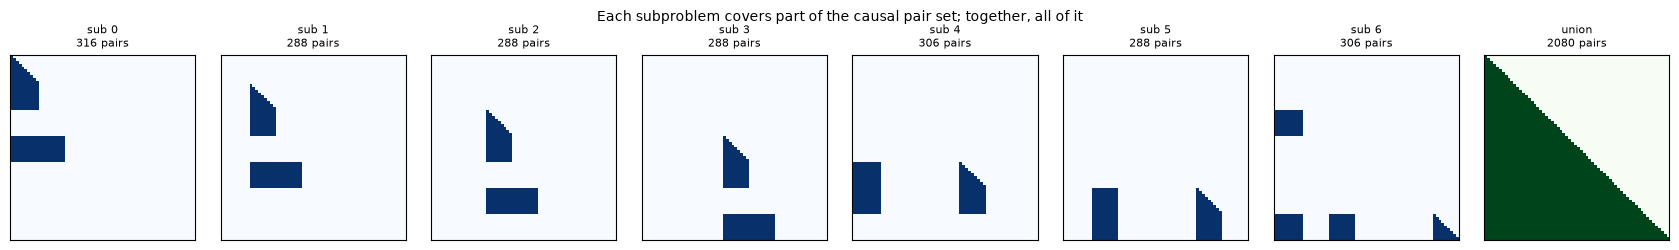

union == full causal mask : True
overlap between subproblems: 2080 pairs covered, 2080 causal pairs total


In [4]:
from stream_cqsa.backends.exact import cqs_keep_mask

N_VIZ = 64
fig, axes = plt.subplots(1, 8, figsize=(17, 2.5))
union = np.zeros((N_VIZ, N_VIZ), dtype=bool)

for i in range(C_CHUNKS):
    m = mask_engine.gen_mask(N=N_VIZ, num_itr=1, quorum_idx=[i])
    tok = np.asarray(m["token_ids"])
    keep_local = cqs_keep_mask(m, device="cpu").numpy()          # [L, L]
    glob = np.zeros((N_VIZ, N_VIZ), dtype=bool)
    glob[np.ix_(tok, tok)] = keep_local
    glob &= np.tril(np.ones_like(glob))                          # causal
    union |= glob
    axes[i].imshow(glob, cmap="Blues", interpolation="nearest")
    axes[i].set_title(f"sub {i}\n{int(glob.sum())} pairs", fontsize=8)
    axes[i].set_xticks([]); axes[i].set_yticks([])

causal_full = np.tril(np.ones((N_VIZ, N_VIZ), dtype=bool))
axes[7].imshow(union, cmap="Greens", interpolation="nearest")
axes[7].set_title(f"union\n{int(union.sum())} pairs", fontsize=8)
axes[7].set_xticks([]); axes[7].set_yticks([])
fig.suptitle("Each subproblem covers part of the causal pair set; together, all of it",
             fontsize=10)
plt.tight_layout(); plt.show()

print("union == full causal mask :", bool((union == causal_full).all()))
print("overlap between subproblems:", int(union.sum()), "pairs covered,",
      int(causal_full.sum()), "causal pairs total")

## 2. The reference runner reproduces dense attention

`stream_cqsa_exact_reference` runs the whole loop: build each subproblem's mask,
gather its tokens, call the inner kernel, and merge the results. Tensors are
`[B, L, H, D]` here (note: **not** the `[B, H, L, D]` layout the production API
uses).

`offload_intermediates=True` performs the merge on the **host**, which is the
reference-scale version of the streaming the production kernel does.

In [5]:
B, N, H, D = 1, 512, 2, 32
q, k, v = (torch.randn(B, N, H, D, device=DEV, dtype=torch.float32) for _ in range(3))

# ground truth: ordinary dense causal attention
ref = torch.nn.functional.scaled_dot_product_attention(
    q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2), is_causal=True
).transpose(1, 2)

print(f"{'itr':>4} {'subproblems':>12} {'rel. error vs dense':>21}")
for itr in (0, 1, 2):
    out, aux = stream_cqsa_exact_reference(q, k, v, itr=itr, causal=True,
                                           c=C_CHUNKS, interest_set=INTEREST,
                                           return_aux=True)
    err = ((out - ref).norm() / ref.norm()).item()
    print(f"{itr:>4} {aux['num_subseq']:>12} {err:>21.3e}")

print("\nfp32 round-off is ~1e-07, so every depth is exact to machine precision.")

 itr  subproblems   rel. error vs dense


   0            1             5.587e-07
   1            7             5.431e-07
   2           49             5.354e-07

fp32 round-off is ~1e-07, so every depth is exact to machine precision.


Errors stay at the fp32 noise floor as the number of subproblems goes
1 -> 7 -> 49. **Error does not compound as subproblems are merged** — the merge
re-bases onto a shared row maximum rather than accumulating drift.

The `aux` dictionary exposes the internals, including where time went.

In [6]:
out, aux = stream_cqsa_exact_reference(q, k, v, itr=1, causal=True, return_aux=True)
print("subproblems      :", aux["num_subseq"])
print("stable recomposition:", aux["stable_softmax"])
print("merged on CPU    :", aux["cpu_offload"])
print("paths            :", aux["paths"])
print("\nper-stage time (ms):")
for kk, vv in aux["transfer_stats"].items():
    if isinstance(vv, (int, float)):
        print(f"  {kk:24s} {vv:10.2f}")

subproblems      : 7
stable recomposition: True
merged on CPU    : True
paths            : [(0,), (1,), (2,), (3,), (4,), (5,), (6,)]

per-stage time (ms):
  communication_ms               0.91
  device_to_host_ms              0.67
  host_to_device_ms              0.24
  t_d2h_ms                       0.67
  t_h2d_ms                       0.24
  t_prepare_ms                   4.11
  t_compute_ms                   8.42
  t_cpu_merge_ms                 1.00
  t_finalize_ms                  0.36
  t_gpu_flush_ms                 0.85
  device_to_host_transfer_gib       0.00
  host_to_device_transfer_gib       0.00


## 3. The inner kernel is pluggable

The decomposition does not care how a subproblem is solved. Any object exposing
the inner-kernel interface can be passed as `inner_kernel=`. Two ship with the
package:

| kernel | how it computes a subproblem | memory |
|---|---|---|
| `DenseExactInnerKernel` | materializes the whole local score matrix | O(L²) |
| `RectangularOutOfCoreInnerKernel` | blocked over Q and K/V tiles, online softmax | O(block²) |

This is the same separation the production CUDA path uses — the CQS scheduling
is independent of the attention kernel underneath.

In [7]:
kernels = {
    "DenseExactInnerKernel": DenseExactInnerKernel(),
    "RectangularOutOfCore (64x64 blocks)":
        RectangularOutOfCoreInnerKernel(q_block_size=64, kv_block_size=64),
    "RectangularOutOfCore (128x128 blocks)":
        RectangularOutOfCoreInnerKernel(q_block_size=128, kv_block_size=128),
}

print(f"{'inner kernel':38s} {'stable merge':>13} {'rel. error':>12}")
for name, kern in kernels.items():
    o = stream_cqsa_exact_reference(q, k, v, itr=1, causal=True, inner_kernel=kern)
    err = ((o - ref).norm() / ref.norm()).item()
    print(f"{name:38s} {str(kern.supports_stable_recomposition):>13} {err:>12.3e}")

inner kernel                            stable merge   rel. error
DenseExactInnerKernel                           True    5.431e-07


RectangularOutOfCore (64x64 blocks)            False    5.370e-07
RectangularOutOfCore (128x128 blocks)          False    5.419e-07


Both reproduce dense attention. Note the `stable merge` column: the
out-of-core kernel reports `False`, meaning it hands back raw `Num`/`Den` rather
than row-max-shifted state. It is numerically careful *internally* — it runs an
online softmax over blocks — but then multiplies by `exp(row_max)` to return
the raw form the merge interface expects.

That detail is the subject of the next section, and it is the single most
important thing this notebook has to say.

## 4. Why the production kernel is written differently

The natural way to recompose subproblems is with an unnormalized numerator and
denominator:

```
Num_i = sum_j exp(s_ij) v_j      Den_i = sum_j exp(s_ij)      O = (sum_i Num_i) / (sum_i Den_i)
```

It is algebraically correct, and it is what the reference above uses when the
inner kernel does not support stable recomposition. **It is also numerically
unusable at realistic score magnitudes**, because `Den` is a sum of `exp` and
`exp` overflows fp32 at `log(x) > 88.72` (`ln FLT_MAX`).

Below we sweep the input scale, which controls how large the logits get, and
compare the raw `Num`/`Den` path against the row-max-shifted one.

In [8]:
print(f"{'scale':>6} {'max log(Den)':>13} {'zeroed rows':>12} "
      f"{'Num/Den error':>14} {'row-max error':>14}")
print("-" * 64)
for s in (1.0, 4.0, 8.0, 12.0, 30.0):
    qs, ks, vs = (torch.randn(1, 128, 1, 32, device=DEV) * s for _ in range(3))
    r = torch.nn.functional.scaled_dot_product_attention(
        qs.transpose(1, 2), ks.transpose(1, 2), vs.transpose(1, 2), is_causal=True
    ).transpose(1, 2)

    num, den = dense_attention_num_den(qs, ks, vs, causal=True)   # the naive form
    naive = normalize_num_den(num, den)
    stable = stream_cqsa_exact_reference(qs, ks, vs, itr=1, causal=True)

    print(f"{s:>6.1f} {den.clamp_min(1e-30).log().max().item():>13.2f} "
          f"{int(den.eq(0).sum()):>12} "
          f"{((naive - r).norm() / r.norm()).item():>14.2e} "
          f"{((stable - r).norm() / r.norm()).item():>14.2e}")

 scale  max log(Den)  zeroed rows  Num/Den error  row-max error
----------------------------------------------------------------
   1.0          5.73            0       4.02e-07       4.05e-07
   4.0         58.44            0       8.09e-07       8.05e-07
   8.0         88.67            2       1.20e+00       2.63e-06
  12.0         88.70            2       1.26e+00       2.17e-06
  30.0         87.82           10       1.31e+00       9.04e-08


Read the last two columns. Up to scale 4 both agree. **At scale 8 the
`Num`/`Den` path is more than 100% wrong** while the row-max path is still at
`1e-06`.

Now look at *how* it fails. `Den` does not come back as `inf` — the helper calls
`torch.nan_to_num(..., posinf=0.0)`, so an overflowed row silently becomes
**zero**, and `Num/Den` for that row becomes zero. There is no exception, no
warning, and no `nan` in the output. Rows just quietly turn into zeros. The
`zeroed rows` column counts them.

In a forward pass that gives you wrong activations. In a **backward** pass the
same substitution appears as `dNum = dO/Den` and `dDen = -rowsum(dO . Num)/Den²`,
so you get silently wrong *gradients* — worse, because training degrades slowly
and the model gets the blame.

**This is why the production kernel never forms `exp(lse)` anywhere.** It carries
`(acc, l, m)` and re-bases onto `m' = max(m, m_i)` so every exponent is `<= 0`
and every intermediate lies in `(0, 1]`; the backward uses the global
log-sum-exp to get `P = exp(s - lse_global) <= 1` by construction. The full
argument is in [`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md).

The reference kernel is the clearest way to *see* the decomposition. It is not
the formulation you should ship.

## 5. The same decomposition over a sparse pattern (LongNet)

CQS schedules *which pairs go to which subproblem*; it does not require that
every pair be present. Composing it with a sparse attention pattern therefore
works unchanged — the union of subproblems reproduces that pattern rather than
the dense one.

LongNet keep mask (256, 256)  density 0.279 (vs 0.502 for dense causal)

 itr   rel. error vs dense LongNet
   1                     8.825e-08


   2                     9.654e-08


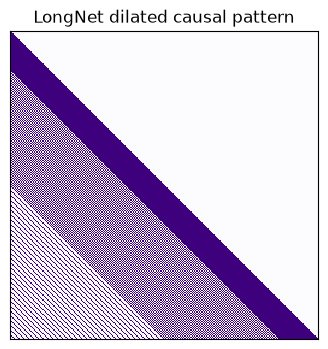

In [9]:
from stream_cqsa.baselines.longnet import (
    build_longnet_keep_mask, stream_cqsa_longnet_reference)

B2, N2, H2, D2 = 1, 256, 1, 32
q2, k2, v2 = (torch.randn(B2, N2, H2, D2, device=DEV) for _ in range(3))
pos = torch.arange(N2, device=q2.device)

keep = build_longnet_keep_mask(pos, segment_lengths=(32, 64, 128),
                               dilation_rates=(1, 2, 4), causal=True, device=q2.device)
print(f"LongNet keep mask {tuple(keep.shape)}  density {keep.float().mean().item():.3f} "
      f"(vs {np.tril(np.ones((N2,N2))).mean():.3f} for dense causal)")

# dense LongNet reference, then the Stream-CQSA decomposition of it
num, den = dense_attention_num_den(q2, k2, v2,
                                   keep_mask=keep.unsqueeze(0).expand(H2, -1, -1),
                                   causal=True)
dense_longnet = normalize_num_den(num, den)

print(f"\n{'itr':>4} {'rel. error vs dense LongNet':>29}")
for itr in (1, 2):
    o = stream_cqsa_longnet_reference(q2, k2, v2, itr=itr, causal=True)
    print(f"{itr:>4} {((o - dense_longnet).norm() / dense_longnet.norm()).item():>29.3e}")

plt.figure(figsize=(4, 4))
plt.imshow(keep.cpu().numpy(), cmap="Purples", interpolation="nearest")
plt.title("LongNet dilated causal pattern"); plt.xticks([]); plt.yticks([])
plt.show()

## Where to go next

This notebook used the reference path throughout. For real work:

```python
from stream_cqsa import stream_cqsa_auto
out = stream_cqsa_auto(q, k, v, causal=True)     # [B, H, N, D], any N that fits host RAM
```

- **[`tutorial_stream_cqsa.ipynb`](tutorial_stream_cqsa.ipynb)** — the production
  API, profiling, and simulating a smaller card.
- **[`accuracy_demo.ipynb`](accuracy_demo.ipynb)** — accuracy against
  FlashAttention-2 and SDPA in fp16/bf16.
- **[`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md)** — the numerical argument in
  section 4, plus the CUDA-level work (block-skipping, register budget).

Two differences to keep in mind when moving from this notebook to the
production API:

| | reference (this notebook) | production |
|---|---|---|
| tensor layout | `[B, L, H, D]` | `[B, H, N, D]` |
| entry point | `stream_cqsa_exact_reference` | `stream_cqsa_auto` / `stream_cqsa_forward` |
| depth | `itr` given explicitly | `itr="auto"` by default |
| speed | pure PyTorch, O(L²) inner kernel | fused CUDA kernel |